# Figure 7C — Open-field arena: representative trajectory occupancy (KDE)

Head-position trajectories for a **representative recording from two
perinatal-insult groups** (Sal-N and LPS-Hx), coloured by Gaussian-KDE spatial
density and expressed as **seconds spent per spatial bin** on a shared colour
scale. Overlaid zone references: the twelve **corner** quarter-circles (one set
per chamber) and the two **gate** circles between chambers.

**Representative selection.** For each group the recording whose
exploration/anxiety ratio is closest to the group-median ratio was chosen
(`data/representative_selection.csv`); the panels shown are the Sal-N and
LPS-Hx representatives.

**Method.** Trajectories are recomputed from the raw DeepLabCut head track
(`data/recordings/<group>/<id>/dlc_filtered.csv`) with the archive movement
pipeline (`lib/oft_movement_analysis.py`), the per-recording arena boundaries
(`boundaries.csv`), and the container frame-rate (`data/video_fps.csv`): gate
radius 30 px and twelve corner quarter-circles (radius capped at 70 px) on the
DLC-density extremes. Spatial density is a 2-D Gaussian KDE of the cleaned head
positions, scaled to seconds per bin.

In [1]:
import sys, io, contextlib, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Arc
from matplotlib.legend_handler import HandlerPatch
from scipy.stats import gaussian_kde

warnings.filterwarnings("ignore")
try:
    plt.rcParams["font.family"] = "Arial"
except Exception:
    pass

HERE = Path.cwd()
DATA = HERE / "data"
REC  = DATA / "recordings"
sys.path.insert(0, str(HERE / "lib"))
import oft_movement_analysis as MA

FPS = pd.read_csv(DATA / "video_fps.csv").set_index("experiment")["container_fps"]

# Representative recording per group (closest to the group-median ratio).
PICKS = [("Sal-N",  "control2022-03-14T14_42_24"),
         ("LPS-Hx", "control2022-02-24T13_38_07")]

GATE_R   = 30.0     # gate-circle radius (px)
CORNER_R = 70.0     # max corner quarter-circle radius (px)
PAD      = 8        # window padding beyond the arena bounds (px)
CORNER_C = GATE_C = "black"
DIV_C    = "0.55"   # chamber-divider reference lines (neutral grey)

pd.read_csv(DATA / "representative_selection.csv")

,group,representative_recording,ratio,group_median_ratio,dist_to_median,n
0,Sal-N,control2022-03-14T14_42_24,0.983,0.983,0.000,5
1,Sal-Hx,control2021-11-08T12_15_37,0.707,0.688,0.019,6
2,LPS-N,LPS_NoPT_NoEE_M32024-06-28T10_04_03,0.798,0.798,0.000,5
3,LPS-Hx,control2022-02-23T11_22_40,0.689,0.672,0.017,8


In [2]:
# --- zone-overlay + trajectory helpers ------------------------------------
def draw_chamber_corners(ax, lx, rx, ty, ly, hy, by, color, maxr=CORNER_R, lw=0.5,
                         transform=None):
    """Twelve non-overlapping corner quarter-circles (one set per chamber),
    each opening into its chamber; radius capped so adjacent arcs never cross.
    An optional `transform` (e.g. a rotation) is applied to every arc."""
    W = rx - lx
    def cr(chh):
        return min(W / 2.0, chh / 2.0, maxr)
    r1, r2, r3 = cr(ly - ty), cr(hy - ly), cr(by - hy)
    tkw = {} if transform is None else {"transform": transform}
    def arc(cx, cy, t1, t2, r):
        ax.add_patch(Arc((cx, cy), 2 * r, 2 * r, theta1=t1, theta2=t2,
                         edgecolor=color, lw=lw, **tkw))
    arc(lx, ty, 0, 90, r1);    arc(rx, ty, 90, 180, r1)
    arc(lx, ly, 270, 360, r1); arc(rx, ly, 180, 270, r1)
    arc(lx, ly, 0, 90, r2);    arc(rx, ly, 90, 180, r2)
    arc(lx, hy, 270, 360, r2); arc(rx, hy, 180, 270, r2)
    arc(lx, hy, 0, 90, r3);    arc(rx, hy, 90, 180, r3)
    arc(lx, by, 270, 360, r3); arc(rx, by, 180, 270, r3)

def _arc_patch(legend, orig_handle, xdescent, ydescent, width, height, fontsize):
    return Arc((width / 2. - xdescent, height / 2. - ydescent), width * 0.95, height * 1.5,
               angle=0, theta1=30, theta2=150, lw=0.7, edgecolor="black")

def _circle_patch(legend, orig_handle, xdescent, ydescent, width, height, fontsize):
    return Circle((width / 2. - xdescent, height / 2. - ydescent), height * 0.55,
                  fill=False, edgecolor="black", lw=0.7)

def analyze(group, rid):
    """Recompute a recording's cleaned head trajectory + per-point KDE density."""
    rd = REC / group / rid
    df = pd.read_csv(rd / "dlc_filtered.csv", skiprows=2)
    b  = pd.read_csv(rd / "boundaries.csv").iloc[0]
    bd = {k: float(b[k]) for k in ("high_y", "low_y", "left_x", "right_x", "mid_x")}
    with contextlib.redirect_stdout(io.StringIO()):
        res = MA.analyze_mouse_movement(df, bd, float(FPS.get(rid, 30.0)),
                                        experiment_name=rid)
    return res, bd

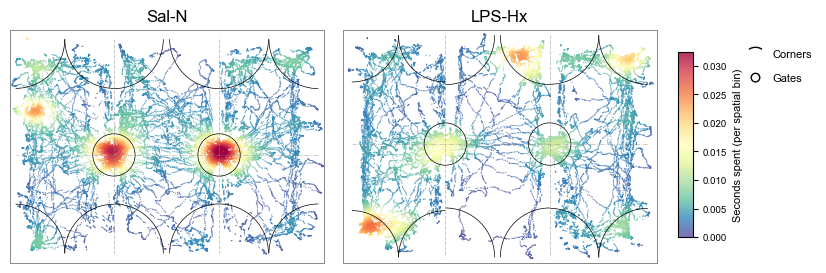

In [3]:
from matplotlib.transforms import Affine2D

# Rotate each arena 90 deg -> landscape (chambers left->right, gates side by
# side), matching the manuscript arrangement.
ROT_DEG = 90

def rotate_xy(px, py, deg):
    a = np.deg2rad(deg)
    return px * np.cos(a) - py * np.sin(a), px * np.sin(a) + py * np.cos(a)

panels = []
for g, rid in PICKS:
    res, bd = analyze(g, rid)
    xy = np.vstack([res["x"], res["y"]])
    z  = gaussian_kde(xy)(xy) * 600.0          # density -> seconds per spatial bin
    ab = res["actual_bounds"]
    panels.append(dict(g=g, res=res, bd=bd, z=z,
                       cx=(ab["min_x"] + ab["max_x"]) / 2,
                       cy=(ab["min_y"] + ab["max_y"]) / 2,
                       ex=ab["max_x"] - ab["min_x"],
                       ey=ab["max_y"] - ab["min_y"]))

HWx  = max(p["ex"] for p in panels) / 2 + PAD
HWy  = max(p["ey"] for p in panels) / 2 + PAD
vmax = max(float(np.quantile(p["z"], 0.99)) for p in panels)

# After a 90 deg rotation the on-screen width/height swap -> wider, shorter panels.
fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.3), facecolor="white")
sc = None
for ax, p in zip(axes, panels):
    cx, cy, bd, res = p["cx"], p["cy"], p["bd"], p["res"]
    z  = p["z"]
    o  = z.argsort()
    rot = Affine2D().rotate_deg(ROT_DEG) + ax.transData
    xc, yc = res["x"] - cx, res["y"] - cy
    xr, yr = rotate_xy(xc[o], yc[o], ROT_DEG)
    sc = ax.scatter(xr, yr, c=z[o], s=3, cmap="Spectral_r", marker=".",
                    lw=0, alpha=0.8, vmin=0, vmax=vmax)
    ab = res["actual_bounds"]
    x0, x1 = ab["min_x"] - cx, ab["max_x"] - cx
    y0, y1 = ab["min_y"] - cy, ab["max_y"] - cy
    # faint chamber references (drawn in arena frame, rotated by `rot`)
    ax.plot([bd["mid_x"] - cx]*2, [y0, y1], color=DIV_C, ls="-.", lw=0.6, alpha=0.5, transform=rot)
    ax.plot([x0, x1], [bd["low_y"] - cy]*2,  color=DIV_C, ls="--", lw=0.7, alpha=0.5, transform=rot)
    ax.plot([x0, x1], [bd["high_y"] - cy]*2, color=DIV_C, ls="--", lw=0.7, alpha=0.5, transform=rot)
    # corner quarter-circles (rotated)
    draw_chamber_corners(ax, x0, x1, y0, bd["low_y"] - cy, bd["high_y"] - cy, y1,
                         color=CORNER_C, maxr=CORNER_R, lw=0.5, transform=rot)
    # gate circles (rotated)
    ax.add_patch(Circle((bd["mid_x"] - cx, bd["low_y"] - cy),  GATE_R, fill=False,
                        edgecolor=GATE_C, lw=0.5, transform=rot))
    ax.add_patch(Circle((bd["mid_x"] - cx, bd["high_y"] - cy), GATE_R, fill=False,
                        edgecolor=GATE_C, lw=0.5, transform=rot))
    # rotated bounding box -> swap half-width / half-height
    ax.set_xlim(-HWy, HWy); ax.set_ylim(HWx, -HWx)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_color("#888"); s.set_linewidth(0.7)
    ax.set_title(p["g"], fontsize=12)

fig.subplots_adjust(left=0.03, right=0.80, top=0.90, bottom=0.05, wspace=0.06)
cax = fig.add_axes([0.825, 0.20, 0.018, 0.56])
cb = fig.colorbar(sc, cax=cax)
cb.set_label("Seconds spent (per spatial bin)", fontsize=8)
cb.ax.tick_params(labelsize=7)
arc_proxy, circ_proxy = Arc((0, 0), 1, 1), Circle((0, 0), 1, fill=False)
fig.legend([arc_proxy, circ_proxy], ["Corners", "Gates"],
           handler_map={arc_proxy: HandlerPatch(patch_func=_arc_patch),
                        circ_proxy: HandlerPatch(patch_func=_circle_patch)},
           loc="upper left", bbox_to_anchor=(0.895, 0.80), frameon=False,
           fontsize=8, handletextpad=0.7, labelspacing=1.3, handlelength=1.6)

fig.savefig("Fig7C.pdf", bbox_inches="tight", facecolor="white")
fig.savefig("Fig7C.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

---
## Cohort context — all individual mice and pooled occupancy

The panel above shows **one representative recording per highlighted group** —
the recording whose exploration/anxiety ratio is closest to the group median
(`data/representative_selection.csv`). For transparency the full golden cohort
is shown below: the per-recording trajectory-KDE montage for **every** mouse,
and the pooled per-group occupancy KDE.

### All individual mice — per-recording trajectory-KDE montage

Rows = group (Sal-N n=5, Sal-Hx n=6, LPS-N n=5, LPS-Hx n=8); each tile is one
recording's head-trajectory KDE in the archive geometry.

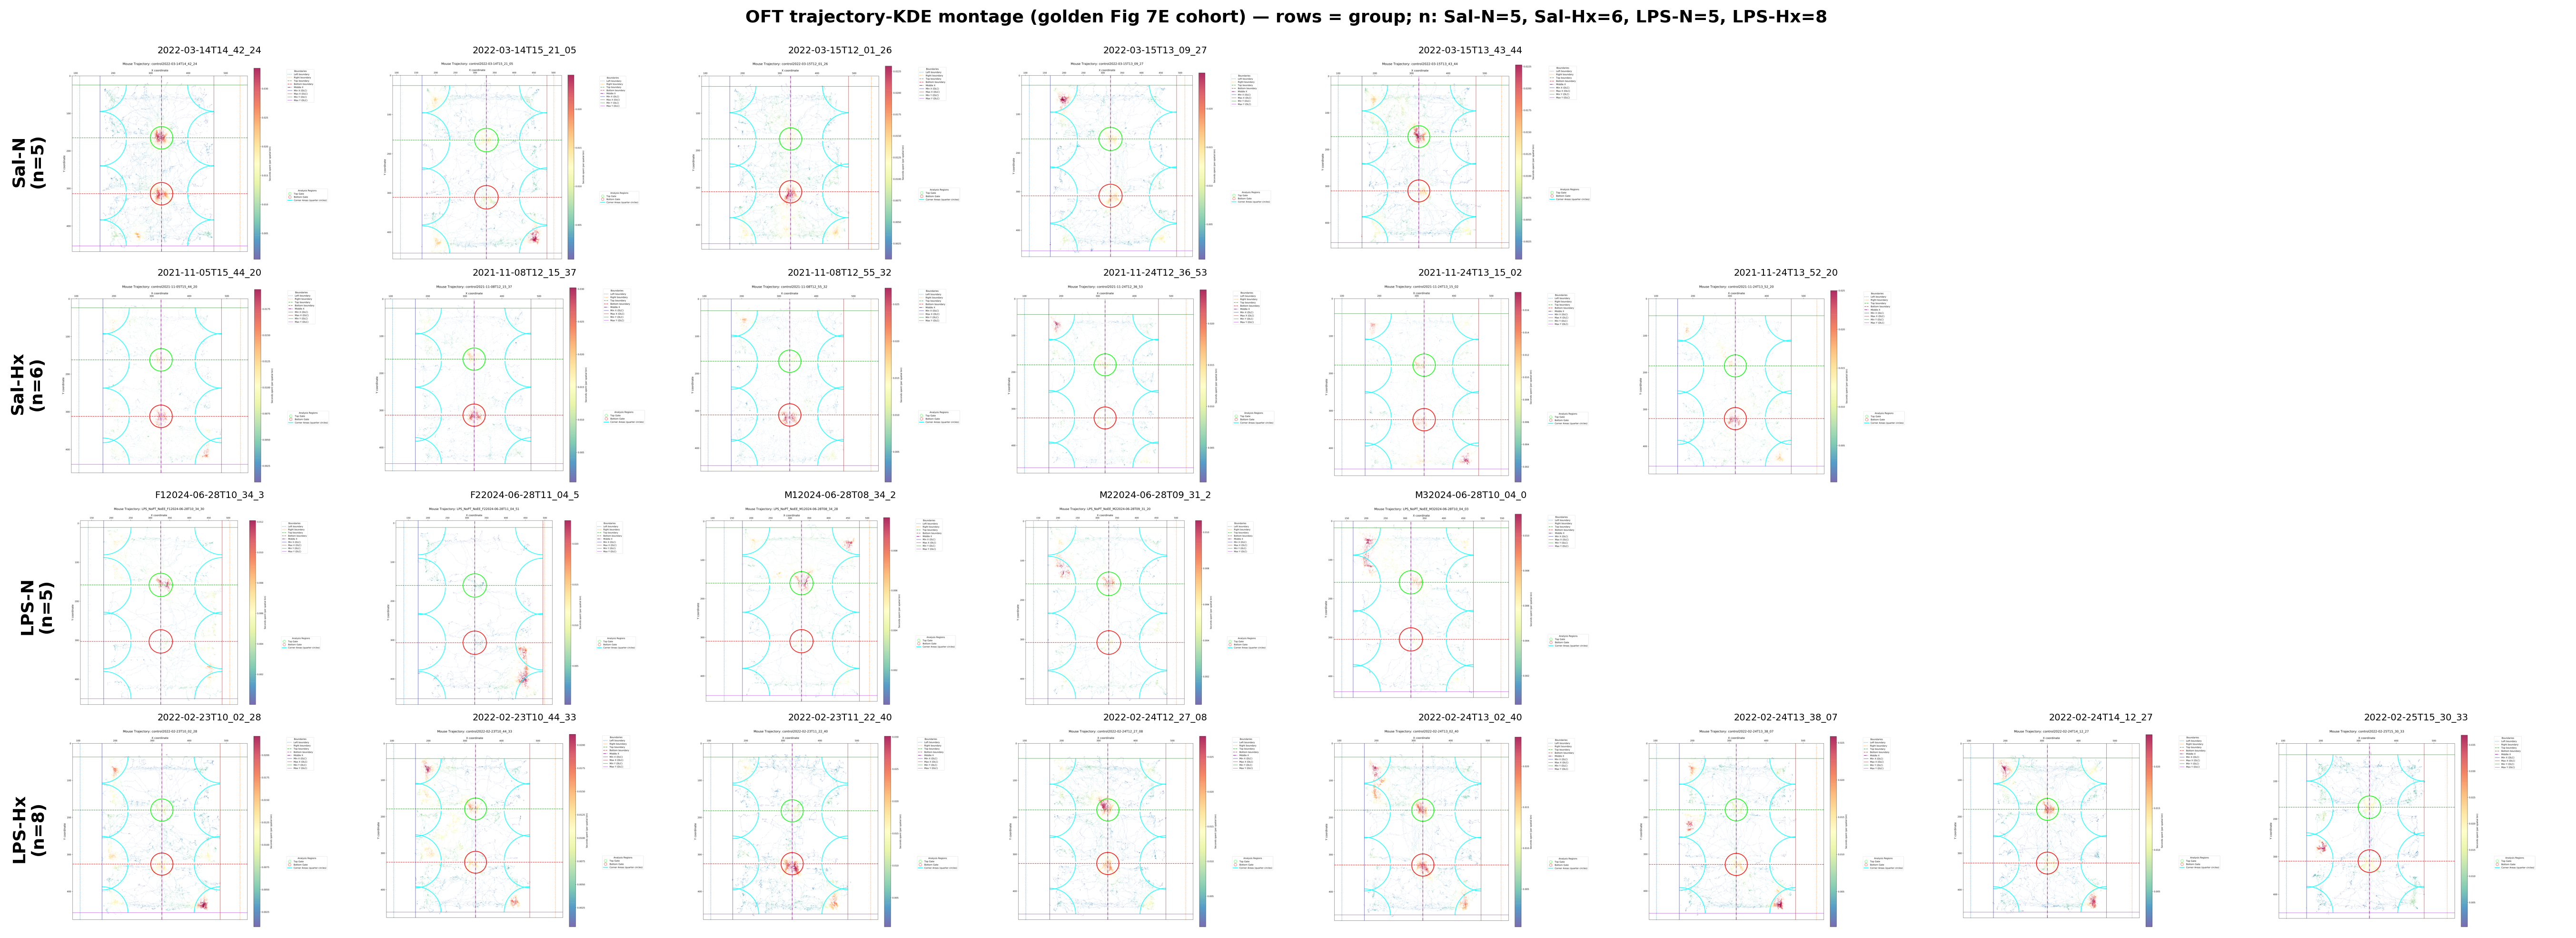

In [4]:
from IPython.display import Image, display
display(Image(filename="supplementary/kde_montage.png"))

### Pooled per-group occupancy KDE

All recordings in each group pooled into a single occupancy KDE
(arena-normalised, equal-time-weighted).

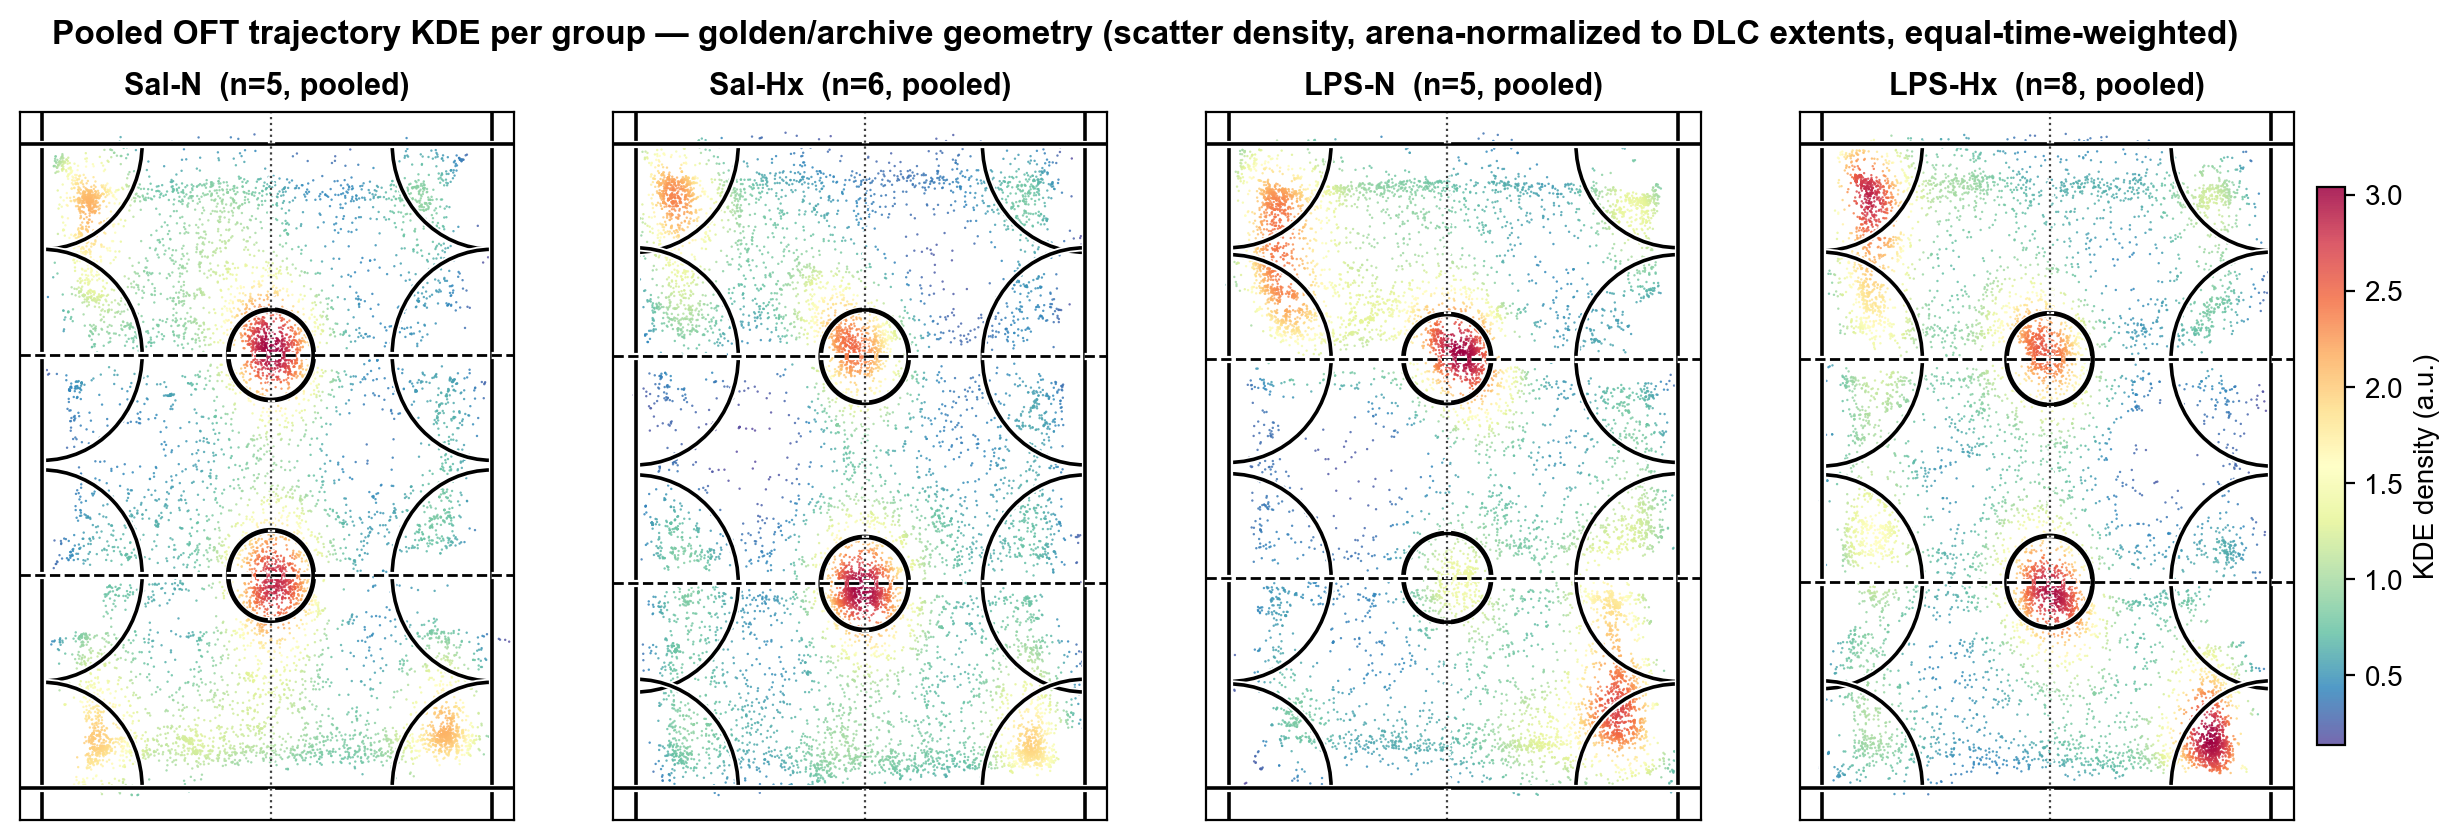

In [5]:
display(Image(filename="supplementary/fig7e_pooled_kde.png"))